<a href="https://colab.research.google.com/github/Sourasree-pramanik18110/Data-Analyst-projects/blob/main/asos_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This contains analysation and visual representation of data from ASOS.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('products_asos.csv', engine='python', encoding='latin1', on_bad_lines='skip')


df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])

print(f"Data Loaded: {len(df)} rows")
df.head()

Data Loaded: 3759 rows


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [ ]:
def get_brand(text):
    try:
        text = str(text).lower()
        if 'by' in text:
            return text.split('by')[1].strip().split()[0]
        return "unknown"
    except:
        return "unknown"

df['brand_raw'] = df['description'].astype(str).apply(get_brand)

In [ ]:
df.head(3)

,url,name,size,category,price,color,sku,description,images,brand_raw
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,new
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,new
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,new


In [ ]:
brand_map ={
    'new':'New look',
    'river':'River Island',
    'miss':'Miss Selfridge',
    'topshopwelcome':'Topshop',
    'asos':'ASOS',
}

df['Brand'] = df['brand_raw'].map(brand_map).fillna(df['brand_raw'])

brand_counts = df['Brand'].value_counts()
valid_brands = brand_counts[brand_counts >= 5].index
df_clean =df[df['Brand'].isin(valid_brands)].copy()

print(df_clean['Brand'].value_counts().head(5))

Brand
ASOS              1110
Topshop            206
New look           164
Miss Selfridge     118
vero               104
Name: count, dtype: int64


In [ ]:
#function to analyze stockouts
def calculate_phantom_revenue(size_str):
    if not isinstance(size_str, str):
        return 0, 0.0
    #split "UK 6, UK 8 - Out of stock" into list
    sizes = size_str.split(',')
    total_sizes = len(sizes)

    #count how many items are out of stock
    out_of_stock_count = sum(1 for s in sizes if 'Out of stock' in s.strip())

    #calculate rate(0.0 to 1.0)
    rate = out_of_stock_count / total_sizes if total_sizes > 0 else 0.0

    return out_of_stock_count, rate


metrics = df_clean['size'].apply(lambda x: calculate_phantom_revenue(x))

df_clean['stockout_count'] = [x[0] for x in metrics]
df_clean['stockout_rate'] = [x[1] for x in metrics]

df_clean['Lost_Revenue'] = df_clean['stockout_count'] * df_clean['price']

cols = ['Brand','name','stockout_count','stockout_rate','Lost_Revenue','price']

print(df_clean.sort_values(by='Lost_Revenue', ascending=False).head(6)[cols])


        Brand                                               name  \
2941  barbour               Barbour Beadnell wax jacket in black   
2715     ASOS  ASOS DESIGN premium real leather trench coat i...   
3093  barbour                Barbour Beadnell wax jacket in navy   
6566     ASOS  ASOS EDITION all over floral embroidered maxi ...   
3413      the  The North Face 1996 Retro Nuptse down jacket i...   
3128      the  The North Face 1996 Retro Nuptse down puffer j...   

      stockout_count  stockout_rate  Lost_Revenue  price  
2941               9       0.900000        1971.0  219.0  
2715               7       0.875000        1540.0  220.0  
3093               6       0.857143        1314.0  219.0  
6566               6       0.750000        1260.0  210.0  
3413               4       0.800000        1200.0  300.0  
3128               4       0.800000        1200.0  300.0  


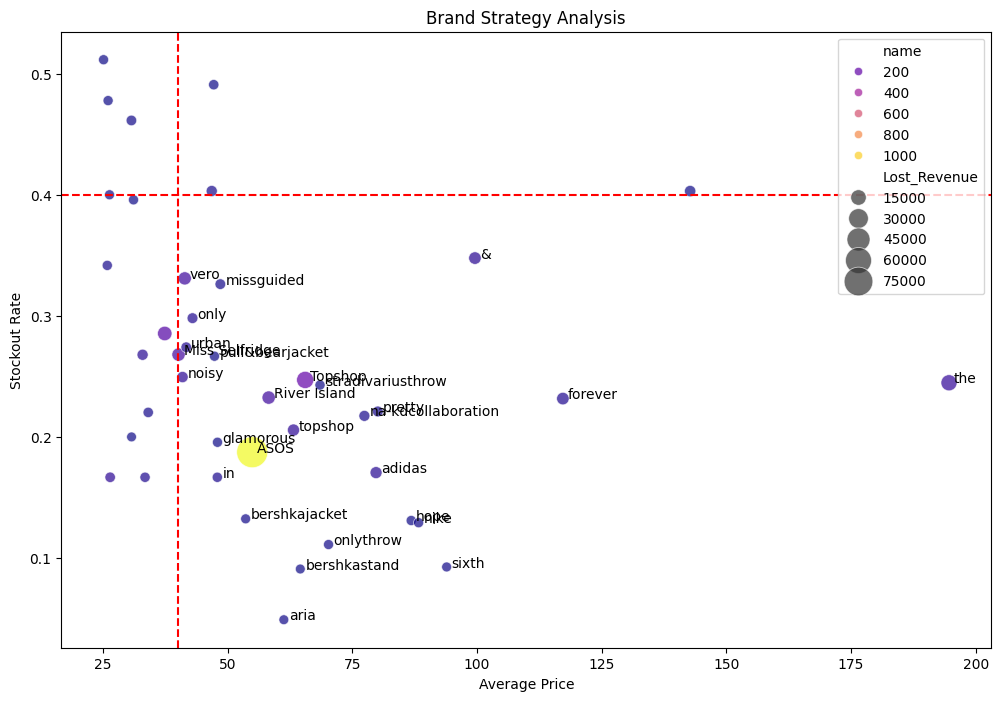

In [ ]:
brand_strategy = df_clean.groupby('Brand').agg({
    'price': 'mean',
    'stockout_rate': 'mean',
    'Lost_Revenue': 'sum',
    'name': 'count',
}).reset_index()

brand_strategy = brand_strategy[brand_strategy['name'] >= 10]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=brand_strategy,
    x='price',
    y='stockout_rate',
    size='Lost_Revenue',
    sizes=(50, 500),
    alpha=0.7,
    hue='name',
    palette='plasma',
)

winners = brand_strategy[
    (brand_strategy['stockout_rate'] < 0.4) & (brand_strategy['price'] >40)
]

for i in range(len(winners)):
    plt.text(
        winners.iloc[i]['price']+1,
        winners.iloc[i]['stockout_rate'],
        winners.iloc[i]['Brand'],
    )

plt.xlabel('Average Price')
plt.ylabel('Stockout Rate')
plt.title('Brand Strategy Analysis')
plt.axvline(x=40, color='red', linestyle='--')
plt.axhline(y=0.4, color='red', linestyle='--')
plt.show()







